import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,Dense,Dropout
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import GRU

Load dataset

In [ ]:
df=pd.read_csv(r"C:\Users\User\Documents\GitHub\My_Ai_Course\Final Assessment\2.Deep Learning Datasets\SpaceX SPCX Stock Price\spacex.csv")
df

,Datetime,Close,High,Low,Open,Volume
0,2026-06-12 15:30:00+00:00,161.309998,168.750000,150.000000,150.000000,90004242
1,2026-06-12 16:00:00+00:00,164.968994,167.770004,155.419998,161.350006,88532026
2,2026-06-12 16:30:00+00:00,173.740005,174.000000,163.070007,164.960007,56616741
3,2026-06-12 17:00:00+00:00,172.279999,176.520004,169.460007,173.720001,44169592
4,2026-06-12 17:30:00+00:00,173.330002,174.000000,168.000000,172.285004,26438783
5,2026-06-12 18:00:00+00:00,169.199997,173.360001,165.050003,173.360001,29089217
6,2026-06-12 18:30:00+00:00,168.850006,170.940002,166.300003,169.294998,21655936
7,2026-06-12 19:00:00+00:00,161.440002,169.229996,161.309998,168.889999,32934441
8,2026-06-12 19:30:00+00:00,161.270004,162.770004,157.440002,161.460007,44594464
9,2026-06-15 13:30:00+00:00,173.630005,175.000000,168.360001,171.809998,60110813


Exploratory Data Analysis (EDA)

In [3]:
df.head()

,Datetime,Close,High,Low,Open,Volume
0,2026-06-12 15:30:00+00:00,161.309998,168.750000,150.000000,150.000000,90004242
1,2026-06-12 16:00:00+00:00,164.968994,167.770004,155.419998,161.350006,88532026
2,2026-06-12 16:30:00+00:00,173.740005,174.000000,163.070007,164.960007,56616741
3,2026-06-12 17:00:00+00:00,172.279999,176.520004,169.460007,173.720001,44169592
4,2026-06-12 17:30:00+00:00,173.330002,174.000000,168.000000,172.285004,26438783


In [4]:
df.shape

(35, 6)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Datetime  35 non-null     str    
 1   Close     35 non-null     float64
 2   High      35 non-null     float64
 3   Low       35 non-null     float64
 4   Open      35 non-null     float64
 5   Volume    35 non-null     int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 1.8 KB


Missing Values

In [6]:
df.isnull().sum()

Datetime    0
Close       0
High        0
Low         0
Open        0
Volume      0
dtype: int64

Figure size

<Axes: xlabel='Datetime'>

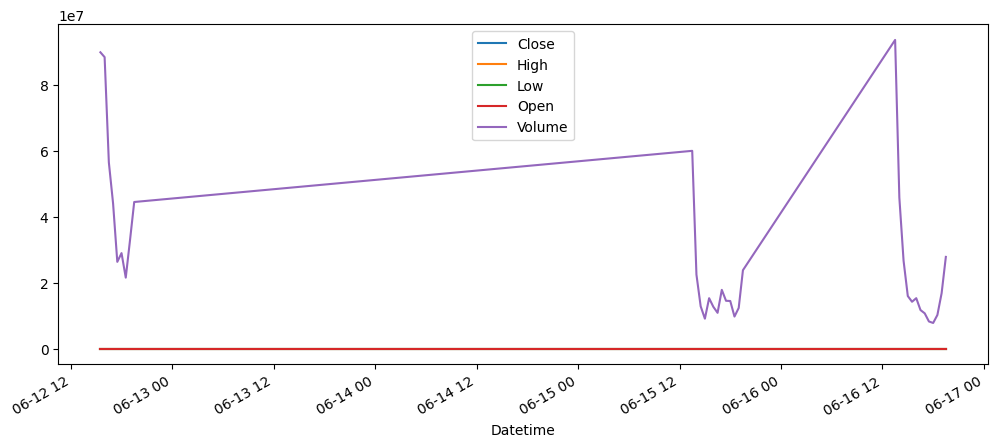

In [11]:
df.plot(figsize=(12,5))

Lenght of the data

In [8]:
len(df)

35

Convert to Time Series

In [9]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df.set_index('Datetime', inplace=True)

df.head()

,Close,High,Low,Open,Volume
Datetime,,,,,
2026-06-12 15:30:00+00:00,161.309998,168.750000,150.000000,150.000000,90004242
2026-06-12 16:00:00+00:00,164.968994,167.770004,155.419998,161.350006,88532026
2026-06-12 16:30:00+00:00,173.740005,174.000000,163.070007,164.960007,56616741
2026-06-12 17:00:00+00:00,172.279999,176.520004,169.460007,173.720001,44169592
2026-06-12 17:30:00+00:00,173.330002,174.000000,168.000000,172.285004,26438783


Data preprocessing

In [14]:
data=df[['Low']]

In [15]:
scaler=MinMaxScaler()
scaled=scaler.fit_transform(data)

Create sequance

In [16]:
def create_dataset(dataset,Low_step=5):
    X=[]
    y=[]
    for i in range(
        len(dataset)-Low_step
    ):
        X.append(
            dataset[i:i+Low_step]
        )
        y.append(
            dataset[i+Low_step]
        )
    return np.array(X),np.array(y)

X,y=create_dataset(scaled,5)

Check

In [17]:
print(X.shape)
print(y.shape)

(30, 5, 1)
(30, 1)


Train-Test Split

In [18]:
split=int(len(X)*0.8)
X_train=X[:split]
X_test=X[split:]
y_train=y[:split]
y_test=y[split:]

RNN model

In [22]:
rnn=Sequential()
rnn.add(
SimpleRNN(
24,
input_shape=(5,1),
activation='tanh'
))
rnn.add(Dropout(0.2))
rnn.add(Dense(1))
rnn.compile(
optimizer='adam',
loss='mse'
)
rnn.summary()

rnn.fit(
X_train,
y_train,
epochs=30,
batch_size=2,
validation_data=(X_test,y_test)
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 24)             │           624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 649 (2.54 KB)

 Trainable params: 649 (2.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - loss: 0.2985 - val_loss: 0.1975
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0717 - val_loss: 0.0323
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.1040 - val_loss: 0.0314
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0819 - val_loss: 0.0225
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0654 - val_loss: 0.0210
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0366 - val_loss: 0.0211
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0546 - val_loss: 0.0239
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0514 - val_loss: 0.0597
Epoch 9/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0331 - val_loss: 0.0200
Epoch 10/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0515 - val_loss: 0.0338
Epoch 11/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0364 - val_loss: 0.0480
Epoch 12/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0

Design LSTM

In [21]:
lstm=Sequential()
lstm.add(
LSTM(
34,
input_shape=(5,1)
))
lstm.add(Dropout(0.2))
lstm.add(Dense(1))
lstm.compile(
optimizer='adam',
loss='mse'
)
lstm.summary()

lstm.fit(
X_train,
y_train,
epochs=24,
batch_size=2,
validation_data=(X_test,y_test)
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 34)             │         4,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 34)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            35 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,931 (19.26 KB)

 Trainable params: 4,931 (19.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/24
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - loss: 0.3315 - val_loss: 0.6230
Epoch 2/24
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2180 - val_loss: 0.3690
Epoch 3/24
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1317 - val_loss: 0.1513
Epoch 4/24
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0500 - val_loss: 0.0280
Epoch 5/24
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0234 - val_loss: 0.0110
Epoch 6/24
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0297 - val_loss: 0.0177
Epoch 7/24
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0257 - val_loss: 0.0122
Epoch 8/24
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0221 - val_loss: 0.0141
Epoch 9/24
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0263 - val_loss: 0.0157
Epoch 10/24
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0181 - val_loss: 0.0134
Epoch 11/24
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0214 - val_loss: 0.0177
Epoch 12/24
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0

Design GRU

In [23]:
gru=Sequential()
gru.add(
GRU(
34,
input_shape=(5,1)
))
gru.add(Dropout(0.2))
gru.add(Dense(1))
gru.compile(
optimizer='adam',
loss='mse'
)
gru.summary()

gru.fit(
X_train,
y_train,
epochs=24,
batch_size=2,
validation_data=(X_test,y_test)
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 34)             │         3,774 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 34)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            35 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,809 (14.88 KB)

 Trainable params: 3,809 (14.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/24
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 0.2829 - val_loss: 0.4271
Epoch 2/24
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1262 - val_loss: 0.1144
Epoch 3/24
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0658 - val_loss: 0.0153
Epoch 4/24
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0335 - val_loss: 0.0096
Epoch 5/24
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0289 - val_loss: 0.0095
Epoch 6/24
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0291 - val_loss: 0.0101
Epoch 7/24
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0362 - val_loss: 0.0094
Epoch 8/24
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0213 - val_loss: 0.0097
Epoch 9/24
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0256 - val_loss: 0.0098
Epoch 10/24
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0301 - val_loss: 0.0110
Epoch 11/24
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0340 - val_loss: 0.0175
Epoch 12/24
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0

Metrics Analysis

In [ ]:
from sklearn.metrics import (
mean_absolute_error,
mean_squared_error,
r2_score
)
def evaluate(
actual,
pred,
name
):
    mae=mean_absolute_error(
        actual,
        pred
    )
    rmse=np.sqrt(
        mean_squared_error(
            actual,
            pred
        )
    )
    r2=r2_score(
        actual,
        pred
    )
    print(name)
    print("MAE :",mae)
    print("RMSE:",rmse)
    print("R2 :",r2)
   